In [ ]:
# ==========================================================
# INSURANCE PURCHASE PREDICTION 
# ==========================================================
# Objective:
# 1) Predict customers likely to buy insurance (imbalanced data)
# 2) Produce marketing-ready probability scores and segments


In [1]:
import imblearn
print(imblearn.__version__)

ImportError: cannot import name '_safe_tags' from 'sklearn.utils._tags' (C:\Users\LAPPKART.COM\Documents\New folder\Lib\site-packages\sklearn\utils\_tags.py)

In [2]:
import sklearn
import imblearn

print(sklearn.__version__)
print(imblearn.__version__)


ImportError: cannot import name '_safe_tags' from 'sklearn.utils._tags' (C:\Users\LAPPKART.COM\Documents\New folder\Lib\site-packages\sklearn\utils\_tags.py)

In [ ]:
# 1. IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

ImportError: cannot import name '_safe_tags' from 'sklearn.utils._tags' (C:\Users\LAPPKART.COM\Documents\New folder\Lib\site-packages\sklearn\utils\_tags.py)

In [ ]:
# 2. LOAD DATASET

In [8]:
df=pd.read_csv("insclimproduct.csv") 

In [9]:
df.head()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0,0,1,1,0


In [ ]:
# 3. DATA CHECKS

In [10]:
df.shape

(595212, 59)

In [11]:
df.isnull().sum().sum()


0

In [ ]:
# Target imbalance check

In [12]:
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True))


target
0    573518
1     21694
Name: count, dtype: int64
target
0    0.963552
1    0.036448
Name: proportion, dtype: float64


In [ ]:
# 4. BASIC EDA

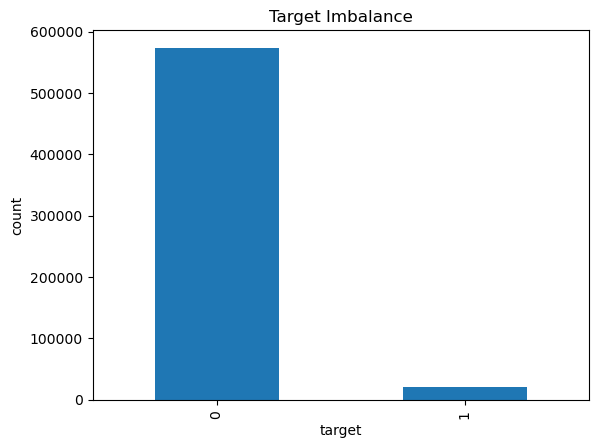

In [13]:
plt.figure()
df['target'].value_counts().plot(kind='bar')
plt.title("Target Imbalance")
plt.xlabel("target")
plt.ylabel("count")
plt.show()


In [14]:
# Correlation with target (quick look)
print(df.corr()['target'].sort_values(ascending=False).head(10))

target           1.000000
ps_car_13        0.053899
ps_car_12        0.038790
ps_ind_17_bin    0.037053
ps_reg_02        0.034800
ps_ind_07_bin    0.034218
ps_car_04_cat    0.032900
ps_car_03_cat    0.032401
ps_reg_03        0.030888
ps_ind_05_cat    0.029165
Name: target, dtype: float64


In [ ]:
# 5. PREPROCESSING & FEATURE SETUP

In [15]:
# Drop ID
df = df.drop(columns=['id'])
X = df.drop("target", axis=1)
y = df["target"]


In [ ]:
# Train/Test split (stratified)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [ ]:
# 6. HANDLE CLASS IMBALANCE (SMOTE)

In [17]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE class balance:\n", y_train_sm.value_counts())


After SMOTE class balance:
 target
0    458814
1    458814
Name: count, dtype: int64


In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [19]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1
)

lr.fit(X_train_scaled, y_train)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

lr_roc = roc_auc_score(y_test, lr_prob)
lr_pr = average_precision_score(y_test, lr_prob)

print("Logistic Regression ROC-AUC:", lr_roc)
print("Logistic Regression Avg Precision:", lr_pr)


Logistic Regression ROC-AUC: 0.6232507015220812
Logistic Regression Avg Precision: 0.05876283280911205


In [20]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:, 1]

rf_roc = roc_auc_score(y_test, rf_prob)
rf_pr = average_precision_score(y_test, rf_prob)

print("Random Forest ROC-AUC:", rf_roc)
print("Random Forest Avg Precision:", rf_pr)


Random Forest ROC-AUC: 0.6225713011718433
Random Forest Avg Precision: 0.059822178885389


In [21]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)  

xgb.fit(X_train, y_train)
xgb_prob = xgb.predict_proba(X_test)[:, 1]

xgb_roc = roc_auc_score(y_test, xgb_prob)
xgb_pr = average_precision_score(y_test, xgb_prob)

print("XGBoost ROC-AUC:", xgb_roc)
print("XGBoost Avg Precision:", xgb_pr)


XGBoost ROC-AUC: 0.6297100349813483
XGBoost Avg Precision: 0.06430319448975388


In [22]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC-AUC": [lr_roc, rf_roc, xgb_roc],
    "Avg Precision": [lr_pr, rf_pr, xgb_pr]
})

print(results)


                 Model   ROC-AUC  Avg Precision
0  Logistic Regression  0.623251       0.058763
1        Random Forest  0.622571       0.059822
2              XGBoost  0.629710       0.064303


In [23]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance.head(10))


          Feature  Importance
5   ps_ind_06_bin    0.063424
16  ps_ind_17_bin    0.054962
27  ps_car_07_cat    0.044587
4   ps_ind_05_cat    0.039368
23  ps_car_03_cat    0.031986
15  ps_ind_16_bin    0.026962
34      ps_car_13    0.024959
6   ps_ind_07_bin    0.024525
8   ps_ind_09_bin    0.021448
2       ps_ind_03    0.020333


In [24]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance.head(10))


          Feature  Importance
5   ps_ind_06_bin    0.063424
16  ps_ind_17_bin    0.054962
27  ps_car_07_cat    0.044587
4   ps_ind_05_cat    0.039368
23  ps_car_03_cat    0.031986
15  ps_ind_16_bin    0.026962
34      ps_car_13    0.024959
6   ps_ind_07_bin    0.024525
8   ps_ind_09_bin    0.021448
2       ps_ind_03    0.020333


In [28]:
y_pred_best = (xgb_prob >= best_threshold).astype(int)

print("Classification Report @ Best Threshold")
print(classification_report(y_test, y_pred_best))

NameError: name 'best_threshold' is not defined

In [25]:
threshold = 0.7
y_marketing = (xgb_prob >= threshold).astype(int)

print("Customers selected for marketing:", y_marketing.sum())


Customers selected for marketing: 2304


In [26]:
final_marketing_list = X_test[y_marketing == 1].copy()
final_marketing_list['probability'] = xgb_prob[y_marketing == 1]

print(final_marketing_list.head())
print("Total selected customers:", final_marketing_list.shape[0])


        ps_ind_01  ps_ind_02_cat  ps_ind_03  ps_ind_04_cat  ps_ind_05_cat  \
388995          0              2          0              0             -1   
112610          1              2          0              1             -1   
400554          1              1          3              0              0   
553025          5              1          7              1              4   
8991            3              1          7              1              0   

        ps_ind_06_bin  ps_ind_07_bin  ps_ind_08_bin  ps_ind_09_bin  \
388995              0              0              1              0   
112610              0              0              0              1   
400554              0              1              0              0   
553025              0              1              0              0   
8991                0              1              0              0   

        ps_ind_10_bin  ...  ps_calc_12  ps_calc_13  ps_calc_14  \
388995              0  ...           1           1

In [27]:
final_marketing_list.to_csv("marketing_customers.csv", index=True)
